In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# ================= INSTALL =================
# !pip install -q transformers torch librosa scikit-learn tqdm

# ================= IMPORTS =================
import os
import numpy as np
import torch
import librosa
from tqdm import tqdm
from collections import Counter

from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

# ================= PATH =================
# DATA_PATH = "/content/drive/MyDrive/SER_Project/"
DATA_PATH = "/home/ahmed/workspace/kfupm/ics504/project/original_datasets/"

EYASE_FOLDER = DATA_PATH + "EYASE/"

# ================= LABELS =================
EMOTION_LABELS = ["neutral", "happy", "sad", "angry"]
LABEL2IDX = {l:i for i,l in enumerate(EMOTION_LABELS)}

emotion_map_eyase = {
    "neu": "neutral",
    "hap": "happy",
    "sad": "sad",
    "ang": "angry"
}

# ================= AUDIO =================
def load_audio(file_path, sr=16000, max_len=5):
    audio, _ = librosa.load(file_path, sr=sr)
    max_samples = sr * max_len

    if len(audio) < max_samples:
        audio = np.pad(audio, (0, max_samples - len(audio)))
    else:
        audio = audio[:max_samples]

    return audio


def augment(audio):
    noise = np.random.randn(len(audio)) * 0.002
    return audio + noise


# ================= LOAD EYASE =================
def load_eyase(folder):
    X, y = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".wav"):

                parts = file.split("_")
                if len(parts) < 2:
                    continue

                code = parts[1][:3].lower()
                label = emotion_map_eyase.get(code)

                if label in LABEL2IDX:
                    path = os.path.join(root, file)
                    X.append(load_audio(path))
                    y.append(LABEL2IDX[label])

    return np.array(X, dtype=np.float32), np.array(y)


X, y = load_eyase(EYASE_FOLDER)

print("TOTAL:", len(X))
print("Distribution:", Counter(y))


# ================= SPLIT (TRAIN / VAL / TEST) =================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", Counter(y_train))
print("Val:", Counter(y_val))
print("Test:", Counter(y_test))




TOTAL: 579
Distribution: Counter({np.int64(0): 150, np.int64(3): 150, np.int64(2): 147, np.int64(1): 132})

Train: Counter({np.int64(0): 105, np.int64(3): 105, np.int64(2): 103, np.int64(1): 92})
Val: Counter({np.int64(3): 23, np.int64(2): 22, np.int64(0): 22, np.int64(1): 20})
Test: Counter({np.int64(0): 23, np.int64(3): 22, np.int64(2): 22, np.int64(1): 20})


In [2]:
# ================= MODEL =================
MODEL_ID = "jonatasgrosman/wav2vec2-large-xlsr-53-english"
processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
base_model = Wav2Vec2Model.from_pretrained(MODEL_ID)


# ================= FREEZE + UNFREEZE =================
# Freeze everything first
for param in base_model.parameters():
    param.requires_grad = False

# UNFREEZE LAST 6 TRANSFORMER LAYERS
for layer in base_model.encoder.layers[-6:]:
    for param in layer.parameters():
        param.requires_grad = True


# ================= DATASET =================
class SERDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        audio = self.X[idx]

        if self.augment and np.random.rand() < 0.4:
            audio = augment(audio)

        # inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)

        return inputs.input_values.squeeze(0), torch.tensor(self.y[idx])


train_ds = SERDataset(X_train, y_train, augment=True)
val_ds   = SERDataset(X_val, y_val)
test_ds  = SERDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)
test_loader  = DataLoader(test_ds, batch_size=4)


# ================= MODEL HEAD =================
class SERModel(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()

        self.wav2vec = base_model

        hidden_size = base_model.config.hidden_size  # 🔥 AUTO FIX

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        x = self.wav2vec(x).last_hidden_state
        x = x.mean(dim=1)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SERModel(base_model, len(EMOTION_LABELS)).to(device)


# ================= LOSS =================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: jonatasgrosman/wav2vec2-large-xlsr-53-english
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# ================= TRAIN =================
EPOCHS = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    correct, total = 0, 0

    for x, yb in tqdm(train_loader):
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(out, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            out = model(x)
            loss = criterion(out, yb)
            val_loss += loss.item()

            preds = torch.argmax(out, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*50)



100%|██████████| 102/102 [00:11<00:00,  8.71it/s]


Epoch 1
Train Loss: 1.3833 | Train Acc: 0.2790
Val   Loss: 1.3780 | Val   Acc: 0.4138
--------------------------------------------------


100%|██████████| 102/102 [00:10<00:00,  9.62it/s]


Epoch 2
Train Loss: 1.3792 | Train Acc: 0.3062
Val   Loss: 1.3681 | Val   Acc: 0.3793
--------------------------------------------------


100%|██████████| 102/102 [00:10<00:00,  9.46it/s]


...

Epoch 28
Train Loss: 0.6311 | Train Acc: 0.7679
Val   Loss: 0.9694 | Val   Acc: 0.6437
--------------------------------------------------


100%|██████████| 102/102 [00:10<00:00,  9.57it/s]


Epoch 29
Train Loss: 0.6321 | Train Acc: 0.7679
Val   Loss: 0.8496 | Val   Acc: 0.6552
--------------------------------------------------


100%|██████████| 102/102 [00:10<00:00,  9.53it/s]


Epoch 30
Train Loss: 0.6002 | Train Acc: 0.7852
Val   Loss: 0.8855 | Val   Acc: 0.6667
--------------------------------------------------



===== TEST CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

     neutral       0.38      0.52      0.44        23
       happy       0.50      0.30      0.38        20
         sad       0.68      0.59      0.63        22
       angry       0.83      0.91      0.87        22

    accuracy                           0.59        87
   macro avg       0.60      0.58      0.58        87
weighted avg       0.60      0.59      0.58        87



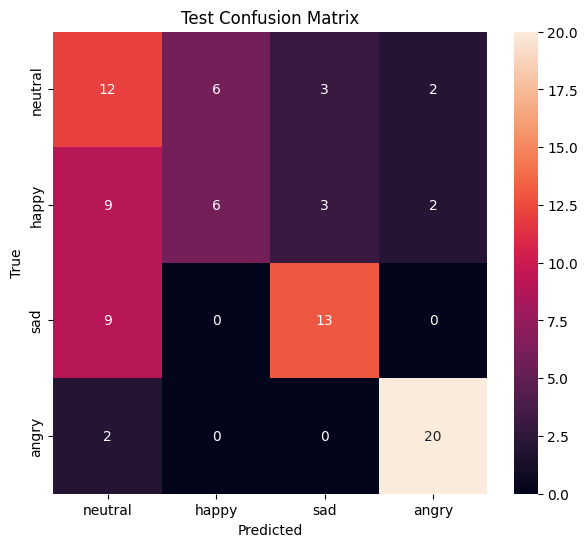

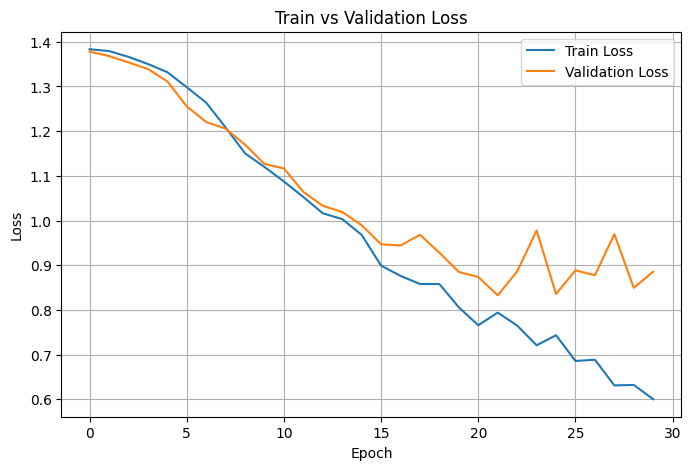

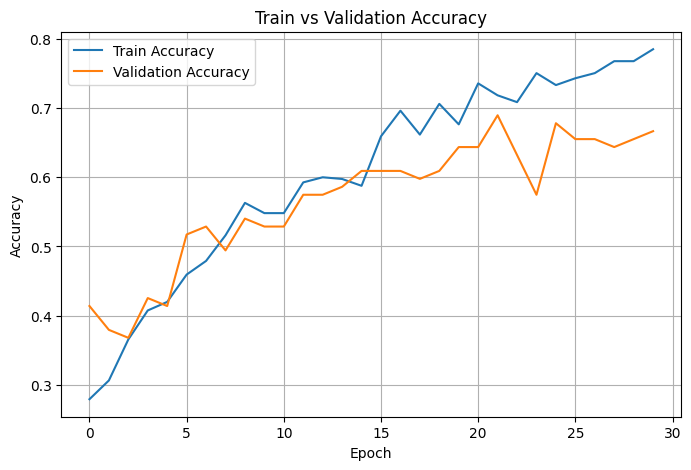

In [4]:
# ================= TEST EVALUATION =================
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, yb in test_loader:
        x = x.to(device)

        out = model(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(yb.numpy())
        y_pred.extend(preds)


print("\n===== TEST CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))


# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS)

plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# ================= CURVES =================
# ===== LOSS CURVE =====
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ===== ACCURACY CURVE =====
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()